In [20]:
import warnings
from pathlib import Path 
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import numpy as np
import pandas as pd


warnings.filterwarnings("ignore")

import data_lake as dl

# from diffusion_contract import RF_KWARGS, RUN_MANIFEST_FILENAME, THRESHOLD_COL


In [21]:
LAYER = "buren"
drivers_path = (dl.ROOT / "analysis" / "topology_diffusion" / "rf_shap_analysis" / LAYER / "topology_to_diffusion" / "threshold_0.3" / "topology_drivers.csv")

In [22]:
mp_paths = list((dl.ROOT / "analysis" / "topology_diffusion" / "rf_shap_analysis" / LAYER / "mp_to_topology").iterdir())

                      topology_feature  influence       xfloor  union_freq  \
0  detected_community_edges_inter_mean   0.053419  1287.301656        1.00   
1        detected_community_n_observed   0.040341   972.155155        0.96   
2   detected_community_edges_inter_std   0.035402   853.132621        1.00   
3  detected_community_edges_inter_skew   0.021337   514.185946        1.00   

   rep_freq  members  driver        kind  \
0      1.00        1    True  stable_rep   
1      0.64        2    True       split   
2      1.00        1    True  stable_rep   
3      1.00        1    True  stable_rep   

                                    rotating_members        r2  
0                                                NaN  0.327839  
1  detected_community_n_observed;detected_communi...  0.432524  
2                                                NaN  0.403093  
3                                                NaN  0.714477  


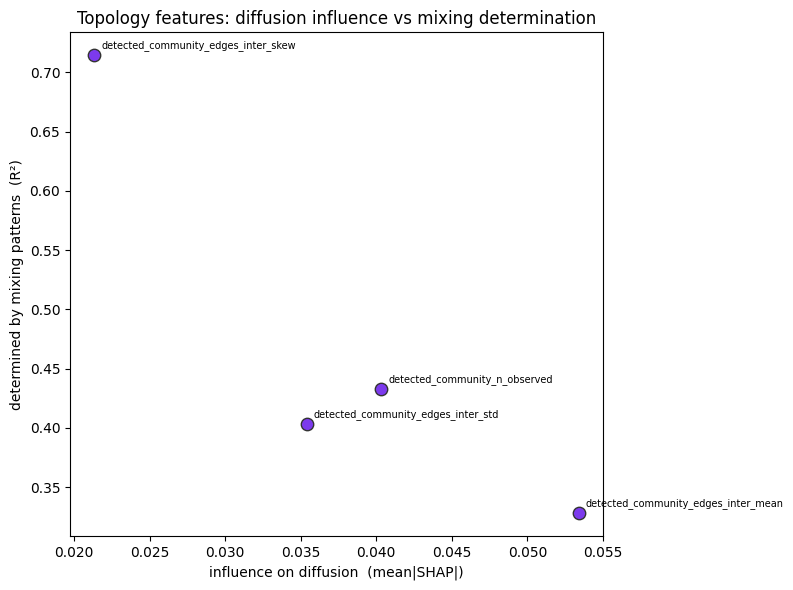

In [23]:
import pandas as pd
import matplotlib.pyplot as plt

# ---- 1. drivers table (topology → diffusion) ----
drivers = pd.read_csv(drivers_path)          # has: topology_feature, influence, xfloor, ...

# ---- 2. collect mixing → topology R² per target ----
rows = []
for path in mp_paths:
    target = path.name                                    # join key
    csv = path / "threshold_0.3" / "univariate_scores.csv"
    if csv.exists():
        u = pd.read_csv(csv, index_col=0)                 # one row per mixing feature
        r2 = u.iloc[:, 0].max()                           # <-- best single mixing feature's R² for this target
        rows.append({"topology_feature": target, "r2": r2})

mixing = pd.DataFrame(rows)

# ---- 3. merge on topology_feature ----
m = drivers.merge(mixing, on="topology_feature", how="inner")
print(m)

# ---- 4. plot: diffusion influence (x) vs mixing determination (y) ----
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(m["influence"], m["r2"], s=80, c="#7c3aed", edgecolors="#333", zorder=3)
for _, r in m.iterrows():
    ax.annotate(r["topology_feature"], (r["influence"], r["r2"]),
                fontsize=7, xytext=(5, 5), textcoords="offset points")
ax.set_xlabel("influence on diffusion  (mean|SHAP|)")
ax.set_ylabel("determined by mixing patterns  (R²)")
ax.set_title("Topology features: diffusion influence vs mixing determination")
plt.tight_layout()
plt.show()